# Phase 3: Geospatial assignment

Load Vienna open data (districts, pedestrian zones, bike paths), attach synthetic coordinates to the telemetry stream, run spatial joins in Spark, and export counts plus maps.

Note: HHAR has no GPS. Coordinates are generated for the simulation. Movement is simplified (straight lines, not real routes).

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.spark_setup import configure_spark_environment, spark_pythonpath_configs
from pyspark.sql import SparkSession

java_home = configure_spark_environment(PROJECT_ROOT)
if java_home is None:
    raise RuntimeError(
        "Java not found. Install with: brew install openjdk@17"
    )

spark_builder = (
    SparkSession.builder
    .appName("Vienna-District-Assignment")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "10")
)

for config_key, config_value in spark_pythonpath_configs(PROJECT_ROOT).items():
    spark_builder = spark_builder.config(config_key, config_value)

if os.name == "nt":
    spark_builder = spark_builder.config("spark.driver.host", "127.0.0.1")

spark = spark_builder.getOrCreate()
print(f"Project root: {PROJECT_ROOT}")
print(f"JAVA_HOME: {java_home}")

26/07/05 17:54:18 WARN Utils: Your hostname, Daniils-MacBook-Pro.local resolves to a loopback address: 127.0.0.1; using 10.250.5.13 instead (on interface en0)
26/07/05 17:54:18 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/05 17:54:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Project root: /Users/daniilvolkov/Desktop/Geospatial-Repletion-Saturation-Modelling-main
JAVA_HOME: /opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home


## Input telemetry

Reads `data/processed/synthetic_telemetry.parquet`. If missing, creates a small test file (30 agents).

In [2]:
from src.create_minimal_telemetry import create_minimal_telemetry

telemetry_path = PROJECT_ROOT / "data" / "processed" / "synthetic_telemetry.parquet"

if not telemetry_path.exists():
    create_minimal_telemetry(PROJECT_ROOT, num_agents=30, samples_per_agent=500)
    spark.catalog.clearCache()

telemetry_df = spark.read.parquet(str(telemetry_path))
print(f"Telemetry rows: {telemetry_df.count()}")
telemetry_df.groupBy("Activity").count().show()

Telemetry rows: 15000


+--------+-----+
|Activity|count|
+--------+-----+
|    walk| 5000|
|    bike| 5000|
|   stand| 5000|
+--------+-----+



## Spatial joins and output

District and infrastructure layers are broadcast to workers. Telemetry is processed in Spark partitions.

In [3]:
from src.geospatial_districts import run_district_assignment

outputs = run_district_assignment(spark, PROJECT_ROOT)
outputs

2026-07-05 17:54:22,010 - INFO - Layer already cached: vienna_districts.geojson


2026-07-05 17:54:22,010 - INFO - Layer already cached: vienna_pedestrian_zones.geojson


2026-07-05 17:54:22,010 - INFO - Layer already cached: vienna_bike_paths.geojson



[Stage 16:>                                                       (0 + 18) / 18]




                                                                                
2026-07-05 17:54:37,681 - INFO - Saved district choropleth map to /Users/daniilvolkov/Desktop/Geospatial-Repletion-Saturation-Modelling-main/data/geospatial_output/district_choropleth.png



                                                                                
2026-07-05 17:54:44,628 - INFO - Saved scatter map to /Users/daniilvolkov/Desktop/Geospatial-Repletion-Saturation-Modelling-main/data/geospatial_output/telemetry_scatter_map.png


2026-07-05 17:54:44,628 - INFO - Geospatial assignment complete.


{'summary_csv': PosixPath('/Users/daniilvolkov/Desktop/Geospatial-Repletion-Saturation-Modelling-main/data/geospatial_output/district_activity_counts.csv'),
 'infrastructure_csv': PosixPath('/Users/daniilvolkov/Desktop/Geospatial-Repletion-Saturation-Modelling-main/data/geospatial_output/infrastructure_activity_counts.csv'),
 'map_png': PosixPath('/Users/daniilvolkov/Desktop/Geospatial-Repletion-Saturation-Modelling-main/data/geospatial_output/district_choropleth.png'),
 'scatter_png': PosixPath('/Users/daniilvolkov/Desktop/Geospatial-Repletion-Saturation-Modelling-main/data/geospatial_output/telemetry_scatter_map.png'),
 'districts_geojson': PosixPath('/Users/daniilvolkov/Desktop/Geospatial-Repletion-Saturation-Modelling-main/data/spatial/vienna_districts.geojson'),
 'pedestrian_geojson': PosixPath('/Users/daniilvolkov/Desktop/Geospatial-Repletion-Saturation-Modelling-main/data/spatial/vienna_pedestrian_zones.geojson'),
 'bike_geojson': PosixPath('/Users/daniilvolkov/Desktop/Geospatia

District summary rows: 21
Unique districts: 15


,district_name,district_number,Activity,time_window_index,count
0,Innere Stadt,1,walk,0,500
1,Leopoldstadt,2,bike,0,500
2,Leopoldstadt,2,stand,0,500
3,Leopoldstadt,2,walk,0,1000
4,Landstraße,3,stand,0,500
5,Margareten,5,stand,0,500
6,Mariahilf,6,stand,0,500
7,Josefstadt,8,walk,0,500
8,Favoriten,10,stand,0,500
9,Favoriten,10,walk,0,2000



Top districts by simulated record count:


,district_name,district_number,count
1,Donaustadt,22,2500
3,Favoriten,10,2500
8,Leopoldstadt,2,2000
13,Simmering,11,1500
4,Floridsdorf,21,1000
12,Penzing,14,1000
0,Brigittenau,20,500
2,Döbling,19,500
5,Innere Stadt,1,500
6,Josefstadt,8,500



Infrastructure assignment totals:


,infrastructure_type,Activity,count
0,bike_path,bike,5000
1,district_centroid,stand,5000
2,pedestrian_zone,walk,5000


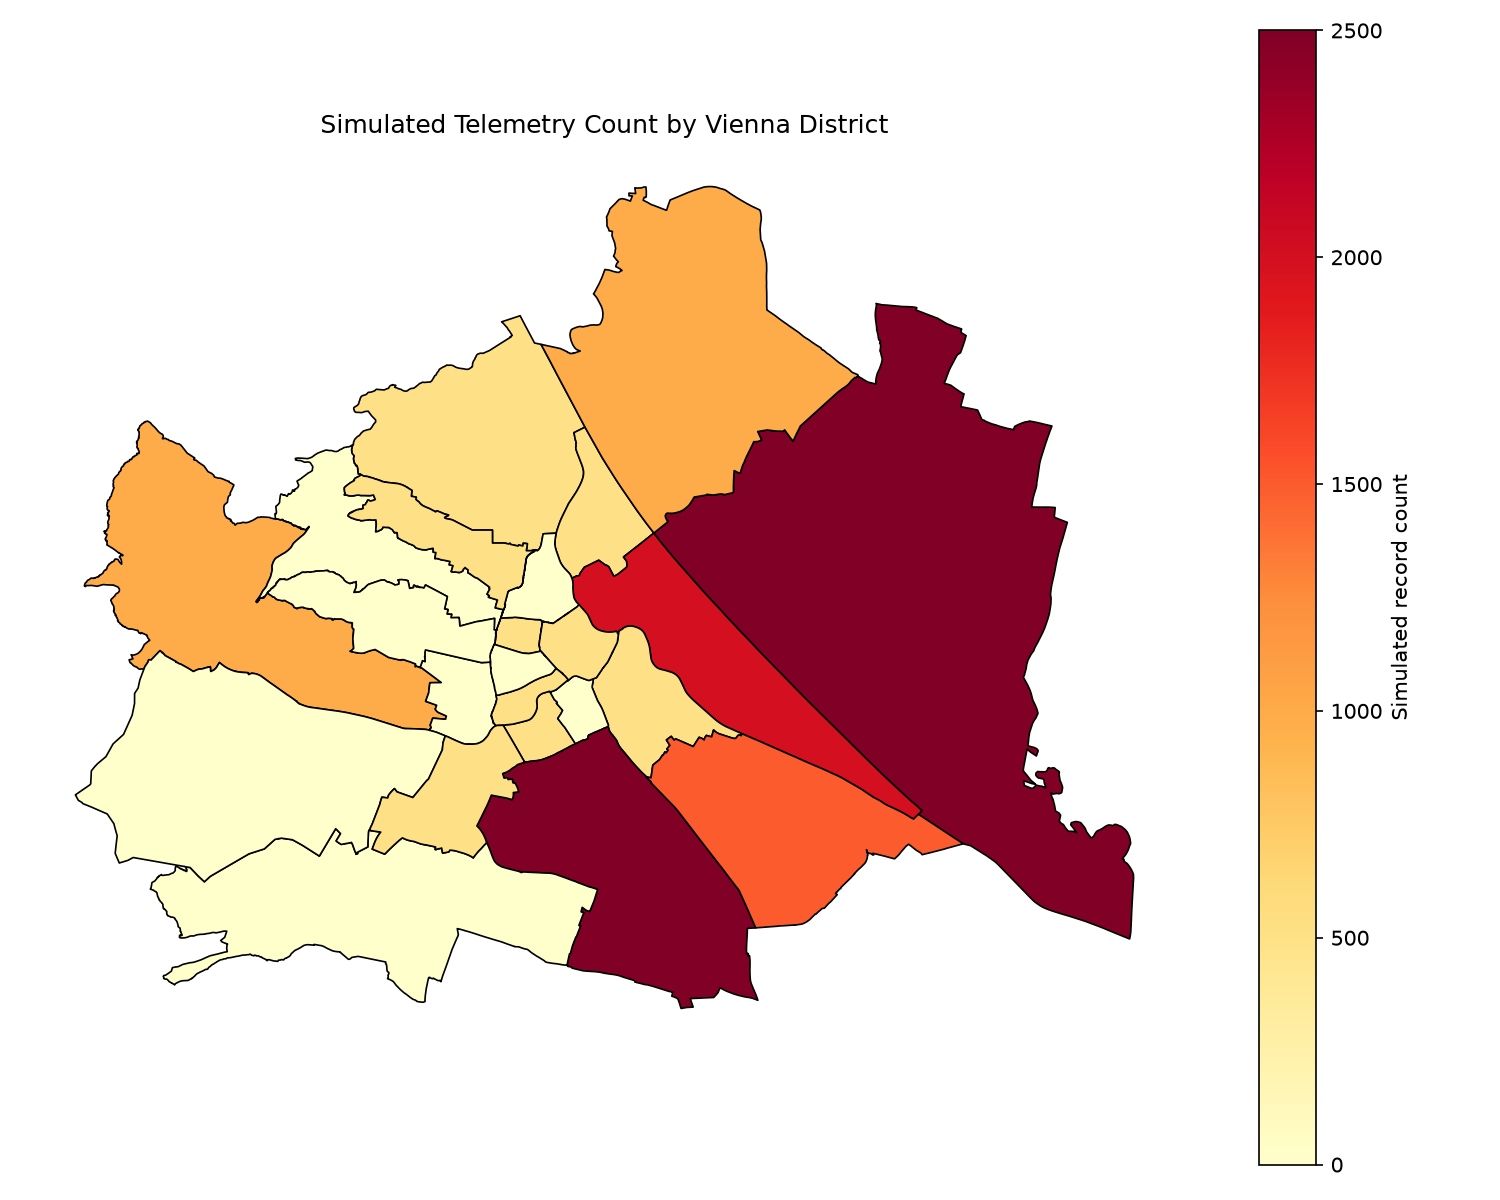

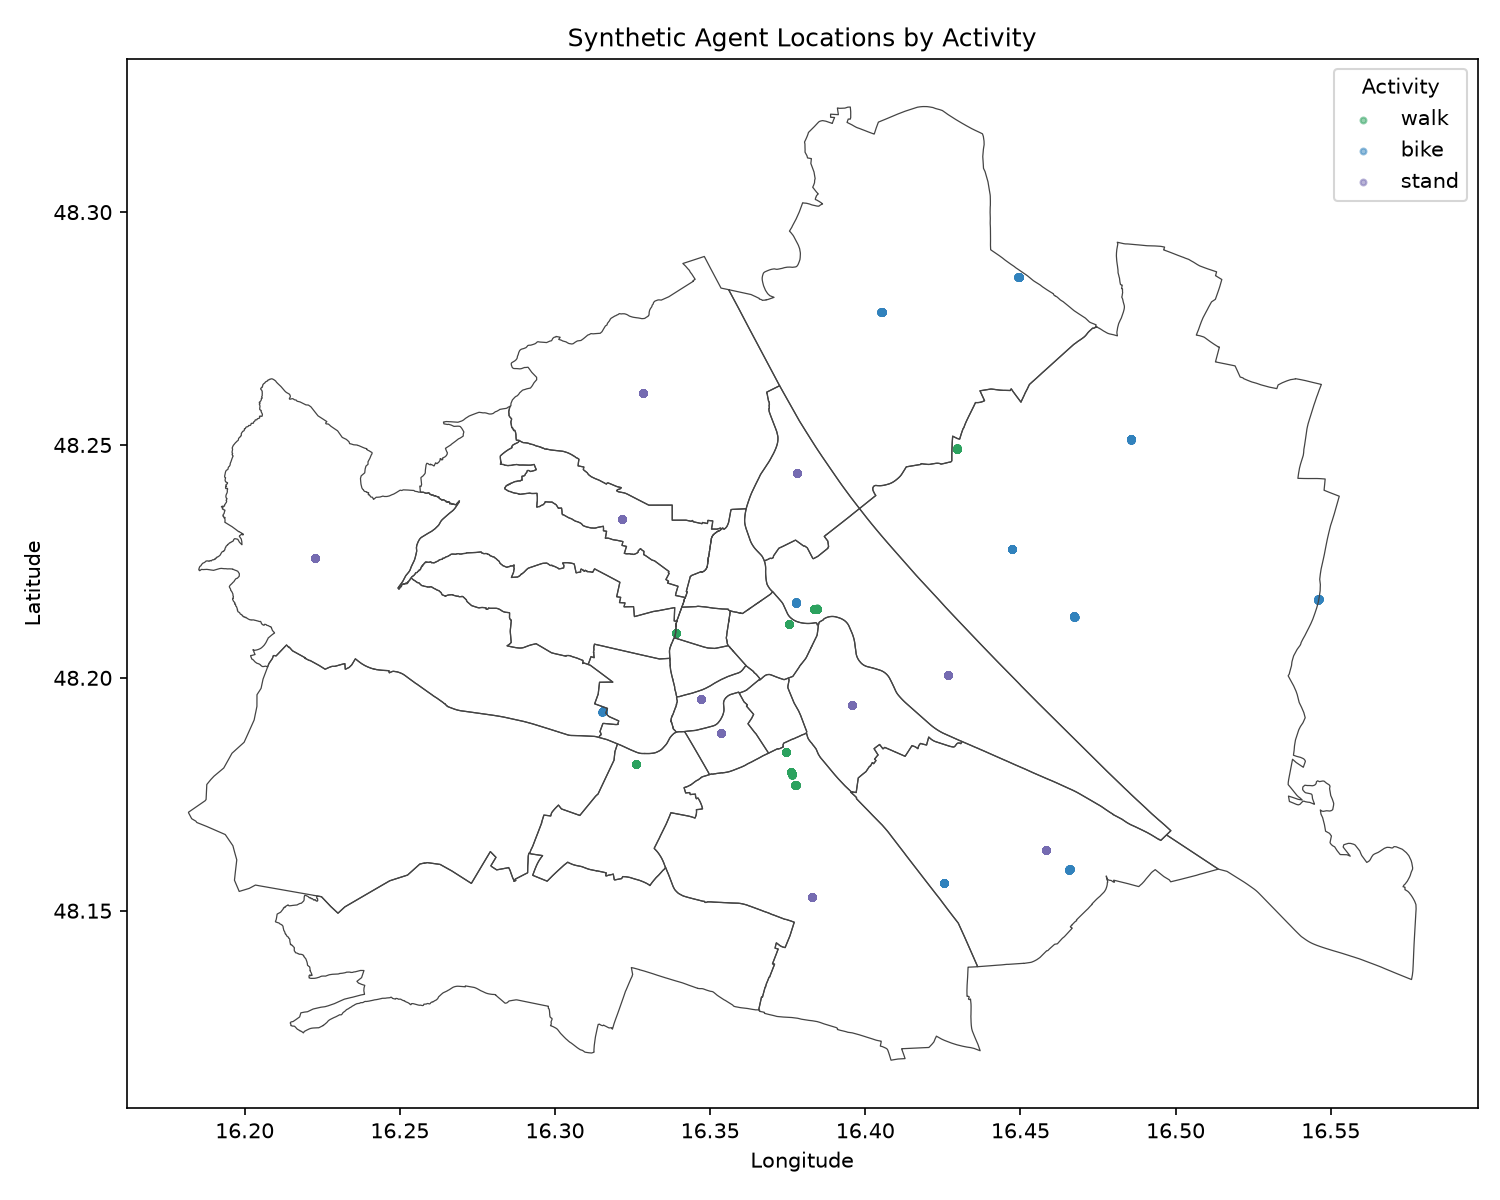

In [4]:
import pandas as pd
from IPython.display import Image, display

summary_df = pd.read_csv(outputs["summary_csv"])
infra_df = pd.read_csv(outputs["infrastructure_csv"])

print(f"District summary rows: {len(summary_df)}")
print(f"Unique districts: {summary_df['district_name'].nunique()}")
display(summary_df.head(20))

district_totals = (
    summary_df.groupby(["district_name", "district_number"], as_index=False)["count"]
    .sum()
    .sort_values("count", ascending=False)
)
print("\nTop districts by simulated record count:")
display(district_totals.head(12))

print("\nInfrastructure assignment totals:")
display(
    infra_df.groupby(["infrastructure_type", "Activity"], as_index=False)["count"]
    .sum()
    .sort_values("count", ascending=False)
)

display(Image(filename=str(outputs["map_png"]), width=700))
display(Image(filename=str(outputs["scatter_png"]), width=700))

## Data sources

- UCI HHAR (CC BY 4.0) — sensor data, no GPS
- City of Vienna OGD (CC BY 4.0 AT): Bezirksgrenzen, Fußgängerzonen, Radwege

Coordinates are synthetic. Counts show how the pipeline works, not real crowd levels in Vienna.

In [5]:
spark.stop()